# Step 1 — Inisialisasi Environment & Pengambilan Video Webcam

Pada tahap ini, kita melakukan dua hal utama:

### 1. Import library yang dibutuhkan
Program rPPG membutuhkan beberapa library:
- **OpenCV (`cv2`)** untuk akses webcam dan pengolahan video.
- **NumPy** untuk manipulasi array numerik.
- **time** untuk menghitung interval waktu antar frame.

Library lain seperti `scipy.signal` akan digunakan di langkah berikutnya
ketika mulai melakukan pemrosesan sinyal (detrending dan bandpass filter).

---

### 2. Membuka kamera dan menampilkan live video
Kita menggunakan:
```python
cap = cv2.VideoCapture(0)

In [1]:
import cv2
import numpy as np
import time

# STEP 1: Membuka webcam dan menampilkan video real-time

cap = cv2.VideoCapture(0)   # 0 = default webcam

if not cap.isOpened():
    raise RuntimeError("Tidak dapat membuka webcam. Cek device index atau driver.")

print("Webcam berhasil dibuka. Tekan 'q' untuk keluar.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Frame tidak berhasil dibaca. Keluar...")
        break

    # Menampilkan video
    cv2.imshow("Step 1 - Live Webcam Feed", frame)

    # Keluar dengan tombol 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Webcam berhasil dibuka. Tekan 'q' untuk keluar.


# Step 2 — Deteksi Wajah Menggunakan Haar Cascade

Pada tahap ini, kita menambahkan kemampuan untuk:
1. **Mendeteksi wajah** pada setiap frame video menggunakan metode *Haar Cascade*.
2. **Menggambar bounding box** pada wajah sebagai indikator bahwa deteksi berhasil.

---

## 🔍 Mengapa perlu deteksi wajah?

Algoritma rPPG membutuhkan area tertentu dari wajah (biasanya **dahi**)
untuk mengekstraksi sinyal warna hijau (G channel).  
Karena itu, program harus mengetahui lokasi wajah terlebih dahulu.

---

## Alat yang digunakan: Haar Cascade Classifier

OpenCV menyediakan pretrained model:
```haarcascade_frontalface_default.xml```


Kelebihannya:
- ringan dan cepat,
- cocok untuk real-time,
- sudah cukup akurat untuk tugas rPPG berbasis webcam.

---

## 📌 Output yang dihasilkan

Setelah menjalankan step ini, kamu akan melihat:
- video webcam,
- dengan **kotak hijau** mengelilingi wajah,
- dan update real-time setiap frame.

Jika bounding box mampu mengikuti wajahmu, berarti deteksi bekerja dengan benar.

In [2]:
import cv2
import numpy as np
import time

# === STEP 2: FACE DETECTION ===

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Tidak dapat membuka webcam.")

print("Deteksi wajah dimulai... Tekan 'q' untuk keluar.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Frame tidak terbaca.")
        break

    # Convert ke grayscale untuk deteksi wajah
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Deteksi wajah pada frame
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5,
        minSize=(100, 100)
    )

    # Gambar bounding box
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cv2.imshow("Step 2 - Face Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Deteksi wajah dimulai... Tekan 'q' untuk keluar.


# Step 3 — Menentukan ROI Dahi & Mengambil Nilai Channel Hijau

Setelah wajah berhasil terdeteksi (Step 2), langkah berikutnya adalah:
1. **Menentukan area ROI (Region of Interest)** pada wajah — khususnya bagian *dahi*.
2. **Menarik rata-rata nilai channel hijau** dari ROI sebagai nilai sinyal rPPG untuk setiap frame.

---

## 🔍 Mengapa dahi dipilih?

- Dahi memiliki **sedikit gerakan otot** dibanding pipi.
- Tidak ditutupi rambut (jika posisi kamera benar).
- Paling stabil untuk sinyal rPPG berbasis webcam.
- Warna kulit lebih konsisten dan memiliki kontribusi sinyal PPG lebih kuat.

---

## Tujuan Step 3

- Menghasilkan **1 nilai** per frame:  
  `mean(G)` dari ROI

Nilai ini:
- Akan menjadi **sinyal mentah** rPPG,
- Disimpan dalam buffer,
- Dan diproses lebih lanjut (Step 4–7) untuk memperoleh BPM.

---

## 📐 Cara mengambil ROI dahi

ROI diambil sebagai bagian atas dari bounding box wajah hasil deteksi:

Dengan proporsi misalnya:
- Lebar: 30%–70% dari bounding box wajah  
- Tinggi: 10%–30% dari bounding box

Proporsi ini fleksibel dan bisa diubah sesuai kebutuhan.

---

## ⚙️ Output Step 3:

Ketika menjalankan kode:
- Sebuah **kotak biru** akan muncul di dahi (ROI)
- Kamu akan mendapatkan nilai *mean green* setiap frame
- Ini adalah sinyal awal yang nanti akan kita simpan dan proses

In [8]:
import cv2
import numpy as np
import time

# Load face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Fungsi: mengambil ROI dahi dari bounding box wajah
def get_forehead_roi(frame, face_rect):
    x, y, w, h = face_rect

    # Proporsi ROI yang lebih ke atas & lebih kecil (lebih pas untuk dahi)
    fx1 = int(x + 0.35 * w)
    fx2 = int(x + 0.65 * w)
    fy1 = int(y + 0.05 * h)
    fy2 = int(y + 0.18 * h)

    fx1 = max(fx1, 0)
    fy1 = max(fy1, 0)
    fx2 = min(fx2, frame.shape[1])
    fy2 = min(fy2, frame.shape[0])

    roi = frame[fy1:fy2, fx1:fx2]
    return roi, (fx1, fy1, fx2, fy2)


cap = cv2.VideoCapture(0)

print("Step 3 - ROI extraction dimulai... Tekan 'q' untuk keluar.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.3, minNeighbors=5, minSize=(100, 100)
    )

    for (x, y, w, h) in faces:
        # gambar kotak wajah
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # ambil ROI dahi
        roi, (fx1, fy1, fx2, fy2) = get_forehead_roi(frame, (x, y, w, h))

        # gambar kotak ROI
        cv2.rectangle(frame, (fx1, fy1), (fx2, fy2), (255, 0, 0), 2)

        if roi.size > 0:
            # ambil channel hijau
            green_channel = roi[:, :, 1]   # BGR → G = index 1
            mean_green = np.mean(green_channel)

            # tampilkan nilai rata-rata G pada layar
            cv2.putText(frame, f"G-mean: {mean_green:.1f}",
                        (fx1, fy2 + 20),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 255, 255), 2)

    cv2.imshow("Step 3 - ROI & Green Extraction", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Step 3 - ROI extraction dimulai... Tekan 'q' untuk keluar.


# Step 4 — Menyimpan Sinyal Mean Green ke Buffer Time-Series

Setelah kita berhasil mengekstraksi nilai **mean green (G-mean)** dari ROI dahi
pada setiap frame (Step 3), kita perlu menyusun data tersebut ke dalam bentuk
**sinyal 1D terhadap waktu**.

Untuk itu, kita melakukan dua hal penting:

---

## 1. Menggunakan `deque` sebagai buffer sinyal
Kita membuat dua buffer:

- `signal_buffer` → berisi nilai rata-rata channel hijau.
- `time_buffer` → berisi timestamp setiap frame (diperoleh dengan `time.time()`).

Kita gunakan `collections.deque` agar buffer:
- memiliki ukuran maksimum (misalnya 300 sampel ≈ 10 detik),
- otomatis membuang sampel lama,
- cepat diakses dan efisien untuk real-time.

---

## 2. Mengumpulkan sinyal dalam sliding window
Tujuan buffer adalah menjaga sinyal dalam **window 10 detik terakhir**,
karena window ini ideal untuk analisis:

- Cukup panjang untuk FFT yang stabil,
- Namun cukup pendek agar deteksi BPM responsif.

---

### 📌 Output Step 4:
Pada akhir step ini kita memiliki:

- `signal_buffer` → sinyal rPPG mentah
- `time_buffer` → waktu pengambilan sampel
- Data siap masuk Step 5 (detrending dan filtering)

Setelah itu, kita baru lakukan analisis frekuensi untuk mendapatkan BPM.


In [10]:
import cv2
import numpy as np
import time
from collections import deque

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# ROI function (from Step 3)
def get_forehead_roi(frame, face_rect):
    x, y, w, h = face_rect
    fx1 = int(x + 0.35 * w)
    fx2 = int(x + 0.65 * w)
    fy1 = int(y + 0.05 * h)
    fy2 = int(y + 0.18 * h)

    roi = frame[fy1:fy2, fx1:fx2]
    return roi, (fx1, fy1, fx2, fy2)

# === STEP 4: BUFFER ===

FPS_ESTIMATE = 30
WINDOW_SECONDS = 10
BUFFER_SIZE = FPS_ESTIMATE * WINDOW_SECONDS

signal_buffer = deque(maxlen=BUFFER_SIZE)
time_buffer = deque(maxlen=BUFFER_SIZE)

cap = cv2.VideoCapture(0)
start_time = time.time()

print("Step 4 - Mengumpulkan sinyal ke buffer (10 detik)...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.3, minNeighbors=5, minSize=(100, 100)
    )

    for (x, y, w, h) in faces:
        # draw face box
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        roi, (fx1, fy1, fx2, fy2) = get_forehead_roi(frame, (x, y, w, h))
        cv2.rectangle(frame, (fx1, fy1), (fx2, fy2), (255, 0, 0), 2)

        if roi.size > 0:
            g_mean = np.mean(roi[:, :, 1])  # ambil channel hijau

            # === SIMPAN KE BUFFER ===
            signal_buffer.append(g_mean)
            time_buffer.append(time.time() - start_time)

            # tampilkan info di layar
            cv2.putText(frame, f"G-mean: {g_mean:.1f}",
                        (fx1, fy2 + 20),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 255, 255), 2)

            cv2.putText(frame, f"Buffer size: {len(signal_buffer)}/{BUFFER_SIZE}",
                        (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, (0, 255, 0), 2)

    cv2.imshow("Step 4 - Buffering Signal", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print("Jumlah data terkumpul:", len(signal_buffer))


Step 4 - Mengumpulkan sinyal ke buffer (10 detik)...
Jumlah data terkumpul: 300


# Step 5 — Detrending & Bandpass Filtering pada Sinyal rPPG

Setelah kita menyimpan nilai rata-rata channel hijau (G-mean) dalam buffer selama ±10 detik (Step 4), sinyal tersebut masih merupakan **sinyal mentah** yang:

- mengandung noise intensitas cahaya,
- terpengaruh gerakan kecil,
- memiliki drift (perubahan lambat),
- dan mengandung banyak komponen frekuensi tidak penting.

Agar sinyal rPPG siap dianalisis menggunakan FFT (Step 6), maka perlu dua tahap kunci:

---

## 1. **Detrending**
Dilakukan menggunakan:

Tujuannya:
- menghilangkan perubahan perlahan (drift),
- menormalkan baseline sinyal,
- membuat komponen jantung lebih terlihat.

---

## 2. **Bandpass Filter (0.67–4 Hz)**
Frekuensi detak jantung manusia secara umum berada di:

- **40–240 BPM**  
- dikonversi ke Hz → **0.67–4 Hz**

Bandpass filter menjaga hanya frekuensi tersebut dan membuang noise lainnya.

Filter yang digunakan:
- Butterworth orde 3
- `scipy.signal.butter` + `scipy.signal.filtfilt`

---

## 🎯 Hasil Step 5:
Kita memperoleh sinyal rPPG yang:
- lebih halus,
- minim noise,
- siap untuk dihitung frekuensinya menggunakan FFT.

In [11]:
import numpy as np
from scipy.signal import butter, filtfilt, detrend
from scipy.fft import rfft, rfftfreq

# STEP 5 — Detrending & Bandpass Filtering

def butter_bandpass(lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, fs, low=0.67, high=4.0):
    if len(data) < 5:
        return data
    b, a = butter_bandpass(low, high, fs)
    return filtfilt(b, a, data)

# Convert deque -> numpy arrays
sig = np.array(signal_buffer)
ts = np.array(time_buffer)

# Estimasi sampling rate (fps aktual)
duration = ts[-1] - ts[0]
if duration <= 0:
    raise ValueError("Durasi waktu tidak valid.")

fs = len(ts) / duration
print(f"Estimated sampling rate (fs): {fs:.2f} Hz")

# Step 5a: detrend
sig_d = detrend(sig, type="linear")

# Step 5b: bandpass filter 0.67–4 Hz
sig_f = bandpass_filter(sig_d, fs, low=0.67, high=4.0)

print("Step 5 selesai — Sinyal berhasil difilter.")
print("Panjang sinyal:", len(sig_f))


Estimated sampling rate (fs): 20.36 Hz
Step 5 selesai — Sinyal berhasil difilter.
Panjang sinyal: 300


# Step 6 — Menghitung BPM dengan Fast Fourier Transform (FFT)

Setelah sinyal rPPG melalui proses:
- detrending, dan
- bandpass filtering (Step 5),

kini sinyal sudah cukup bersih untuk dianalisis menggunakan **FFT (Fast Fourier Transform)**.

---

## Mengapa FFT diperlukan?

Detak jantung muncul sebagai **osilasi periodik** kecil pada sinyal channel hijau.  
FFT mengubah sinyal dari domain waktu → domain frekuensi untuk melihat:

- frekuensi apa yang paling dominan,
- amplitudo getaran sinyal,
- dan frekuensi tersebut dikonversi menjadi **BPM** (Beat Per Minute).

---

## Proses Step 6:

1. Ambil sinyal hasil filtering (`sig_f`)  
2. Hitung FFT:  
```yf = |FFT(sig_f)|```
```xf = frekuensi dalam Hz```
3. Batasi analisis pada rentang detak jantung manusia:
- **0.67–4.0 Hz** = **40–240 BPM**
4. Cari frekuensi dengan amplitudo terbesar  
5. Konversi ke BPM:  

## Output Step 6:
Kita akan mendapatkan nilai BPM yang dihitung dari sinyal rPPG.

In [12]:
# STEP 6 — FFT dan Estimasi BPM

import numpy as np
from scipy.fft import rfft, rfftfreq

# Pastikan sinyal hasil filter ada
if len(sig_f) < 10:
    raise ValueError("Sinyal terlalu pendek untuk FFT.")

# Hitung FFT
N = len(sig_f)
yf = np.abs(rfft(sig_f))
xf = rfftfreq(N, 1.0 / fs)

# Rentang detak jantung manusia (Hz)
f_min = 0.67  # 40 BPM
f_max = 4.00  # 240 BPM

# Ambil indeks yang sesuai
valid_idx = np.where((xf >= f_min) & (xf <= f_max))[0]

if len(valid_idx) == 0:
    raise ValueError("Tidak ada frekuensi dalam rentang BPM manusia.")

# Cari puncak frekuensi (amplitudo terbesar)
idx_peak = valid_idx[np.argmax(yf[valid_idx])]
peak_freq = xf[idx_peak]

# Konversi frekuensi puncak → BPM
bpm = peak_freq * 60.0

print("--- HASIL FFT ---")
print(f"Peak frequency : {peak_freq:.4f} Hz")
print(f"Estimated BPM  : {bpm:.2f}")


--- HASIL FFT ---
Peak frequency : 0.8143 Hz
Estimated BPM  : 48.86


# Step 7 — Implementasi Real-time rPPG (BPM) dengan Pipeline Lengkap

Ini adalah tahap akhir dari seluruh proses rPPG.  
Pada langkah ini, semua komponen dari Step 1 hingga Step 6 digabungkan menjadi satu alur:

---

## Pipeline Lengkap Real-time rPPG

1. **Capture frame dari webcam**  
2. **Deteksi wajah menggunakan Haar Cascade**  
3. **Tentukan ROI dahi**  
4. **Hitung rata-rata intensitas channel hijau (G-mean)**  
5. **Masukkan G-mean ke buffer time-series (10 detik)**  
6. **Jika buffer cukup panjang:**  
   - *detrending sinyal*  
   - *bandpass filtering* (0.67–4 Hz)  
   - *FFT* untuk menemukan frekuensi dominan  
   - *konversi ke BPM*  
7. **Tampilkan BPM langsung pada frame video**

---

## Hasil Step 7:

Setelah menjalankan kode ini, kamu akan melihat:

- kotak hijau (deteksi wajah),  
- kotak biru (ROI dahi),  
- nilai G-mean,  
- nilai BPM real-time di pojok kiri atas,  
- pembacaan stabil setelah ±10 detik (buffer penuh).

Pipeline ini bisa ditingkatkan di bagian:
- POS/CHROM algorithm  
- Denoising tambahan  
- Tracking ROI  
- Auto-light correction  
- dll.

In [8]:
import cv2
import numpy as np
import time
from collections import deque
from scipy.signal import butter, filtfilt, detrend
from scipy.fft import rfft, rfftfreq

# === FACE DETECTOR ===
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# === ROI FUNCTION (Dahi) ===
def get_forehead_roi(frame, face_rect):
    x, y, w, h = face_rect

    fx1 = int(x + 0.35 * w)
    fx2 = int(x + 0.65 * w)
    fy1 = int(y + 0.05 * h)
    fy2 = int(y + 0.18 * h)

    roi = frame[fy1:fy2, fx1:fx2]
    return roi, (fx1, fy1, fx2, fy2)

# === BANDPASS FILTER ===
def butter_bandpass(lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return b, a

def bandpass_filter(data, fs, low=0.67, high=4.0):
    if len(data) < 5:
        return data
    b, a = butter_bandpass(low, high, fs)
    return filtfilt(b, a, data)

# === BUFFER SETTING ===
FPS_ESTIMATE = 30
WINDOW_SECONDS = 10
BUFFER_SIZE = FPS_ESTIMATE * WINDOW_SECONDS

signal_buffer = deque(maxlen=BUFFER_SIZE)
time_buffer = deque(maxlen=BUFFER_SIZE)

cap = cv2.VideoCapture(0)
start_time = time.time()
prev_t = start_time
fps_smooth = FPS_ESTIMATE

print("Real-time rPPG dimulai... Tekan 'q' untuk keluar.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # FPS estimation
    now = time.time()
    dt = now - prev_t
    prev_t = now
    if dt > 0:
        fps_smooth = 0.9 * fps_smooth + 0.1 * (1.0 / dt)

    # ===== Step 2: Face Detection =====
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.3, minNeighbors=5, minSize=(100, 100)
    )

    bpm_text = "BPM: --"

    if len(faces) > 0:
        (x, y, w, h) = faces[0]

        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # ===== Step 3: ROI Extraction =====
        roi, (fx1, fy1, fx2, fy2) = get_forehead_roi(frame, (x, y, w, h))
        cv2.rectangle(frame, (fx1, fy1), (fx2, fy2), (255, 0, 0), 2)

        if roi.size > 0:
            g_mean = np.mean(roi[:, :, 1])

            # ===== Step 4: Buffer =====
            signal_buffer.append(g_mean)
            time_buffer.append(now - start_time)

            # Display G-mean value
            cv2.putText(frame, f"G-mean: {g_mean:.1f}",
                        (fx1, fy2 + 20),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 255, 255), 2)

            # ===== Step 5 & 6: Signal Processing =====
            if len(signal_buffer) >= int(3 * fps_smooth): 
                sig = np.array(signal_buffer)
                ts = np.array(time_buffer)

                # Sampling rate aktual
                duration = ts[-1] - ts[0]
                if duration > 0:
                    fs = len(ts) / duration
                else:
                    fs = fps_smooth

                # Detrend & filter
                sig_d = detrend(sig, type="linear")
                sig_f = bandpass_filter(sig_d, fs)

                # FFT
                N = len(sig_f)
                yf = np.abs(rfft(sig_f))
                xf = rfftfreq(N, 1.0 / fs)

                f_min, f_max = 0.67, 4.0
                valid_idx = np.where((xf >= f_min) & (xf <= f_max))[0]

                if len(valid_idx) > 0:
                    idx_peak = valid_idx[np.argmax(yf[valid_idx])]
                    peak_freq = xf[idx_peak]
                    bpm = peak_freq * 60.0
                    bpm_text = f"BPM: {bpm:.1f}"

    # ===== DISPLAY =====
    cv2.putText(frame, bpm_text, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                (0, 0, 255), 2)

    cv2.putText(frame, f"FPS: {fps_smooth:.1f}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (0, 255, 255), 1)

    cv2.imshow("Real-time rPPG Final", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Real-time rPPG dimulai... Tekan 'q' untuk keluar.


# Step 8 — Visualisasi Gelombang Sinyal rPPG dan Spektrum Frekuensi

Pada tahap ini, kita akan memvisualisasikan sinyal rPPG yang sebelumnya
dikumpulkan dalam `signal_buffer` dan `time_buffer`.

Tujuan:
1. Menampilkan **gelombang rPPG** (domain waktu) mirip bentuk sinyal detak jantung.
2. Menampilkan **spektrum frekuensi** sinyal untuk melihat puncak frekuensi
   yang digunakan dalam perhitungan BPM.

Langkah:
- Gunakan data `signal_buffer` dan `time_buffer` yang diisi selama proses
  real-time rPPG (Step 7).
- Lakukan kembali proses detrending dan bandpass filtering.
- Plot:
  - Sinyal terhadap waktu (time series).
  - Amplitudo terhadap frekuensi (FFT).

Catatan penting:
➡️ Jalankan *REAL-TIME rPPG Final* (Step 7) terlebih dahulu dan biarkan berjalan
   beberapa detik, lalu tekan `q` untuk menutup jendela.
➡️ Setelah itu baru jalankan cell visualisasi ini.


Durasi sinyal: 10.06 s, fs ≈ 29.84 Hz, N = 300


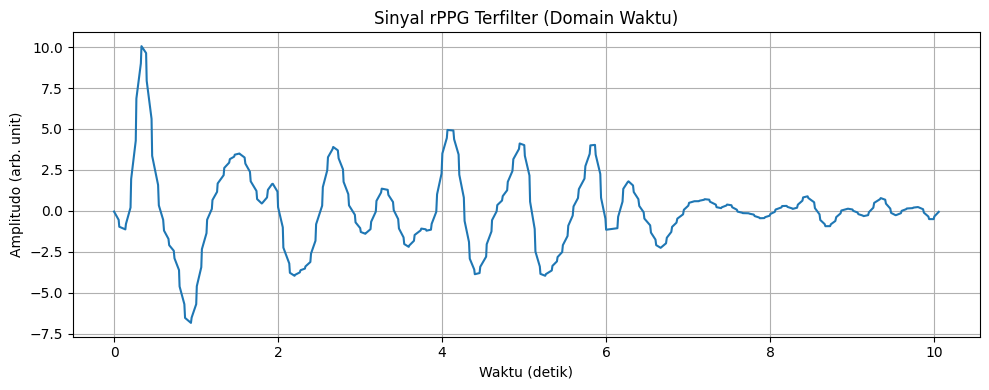

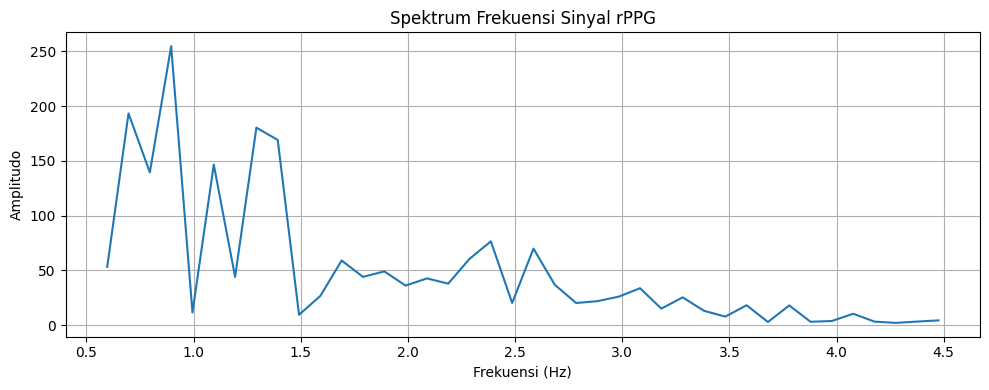

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

# Pastikan buffer tidak kosong
if len(signal_buffer) < 30:
    raise ValueError("Buffer sinyal terlalu pendek. Jalankan dulu real-time rPPG, lalu tutup dengan 'q'.")

# Ambil data dari buffer
sig_raw = np.array(signal_buffer, dtype=np.float64)
ts = np.array(time_buffer, dtype=np.float64)

# Normalisasikan waktu mulai dari 0
t = ts - ts[0]

# Estimasi sampling rate
duration = t[-1] - t[0]
fs = len(t) / duration
print(f"Durasi sinyal: {duration:.2f} s, fs ≈ {fs:.2f} Hz, N = {len(t)}")

# Detrend dan bandpass (pakai fungsi yang sudah ada)
sig_d = detrend(sig_raw, type="linear")
sig_f = bandpass_filter(sig_d, fs, low=0.67, high=4.0)

# ---- Plot time-domain (gelombang) ----
plt.figure(figsize=(10, 4))
plt.plot(t, sig_f)
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo (arb. unit)")
plt.title("Sinyal rPPG Terfilter (Domain Waktu)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot frequency-domain (spektrum) ----
from scipy.fft import rfft, rfftfreq

N = len(sig_f)
yf = np.abs(rfft(sig_f))
xf = rfftfreq(N, 1.0/fs)

# Fokus hanya di rentang detak jantung
f_min, f_max = 0.5, 4.5
mask = (xf >= f_min) & (xf <= f_max)

plt.figure(figsize=(10, 4))
plt.plot(xf[mask], yf[mask])
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Amplitudo")
plt.title("Spektrum Frekuensi Sinyal rPPG")
plt.grid(True)
plt.tight_layout()
plt.show()
